# Tiền xử lý bước 2 (này đúng là bước 3 theo tác giả, nhưng bước 2 của tác giả bị lược bỏ vì nó chỉ map itemID vào df_meta)

## Bước này tạo files:

- text_feat.npy (xài sentence_transformer)
- image_feat.npy (đọc file image_features_Sports_and_Outdoors.b tìm có text mà không có hình fill giá trị mặc định)

## ref:

- https://www.sbert.net/docs/sentence_transformer/pretrained_models.html
- https://github.com/openai/CLIP (Cái này dùng tạo image feature và text feature)


# Sports14 Text/Image Feature Extraction


In [4]:
import os
import torch
import numpy as np
import pandas as pd

In [5]:
PATH = "./data/2014"

In [106]:
df_meta = pd.read_parquet(os.path.join(PATH, "df_meta.parquet"))

In [107]:
df_meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 7037 entries, 0 to 7036
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         7037 non-null   str    
 1   categories   7037 non-null   object 
 2   description  6956 non-null   str    
 3   title        7037 non-null   str    
 4   price        6883 non-null   float64
 5   imUrl        7037 non-null   str    
 6   brand        4926 non-null   str    
 7   related      6946 non-null   object 
 8   salesRank    4 non-null      object 
dtypes: float64(1), object(3), str(5)
memory usage: 4.9+ MB


In [108]:
df_meta.head(3)

,asin,categories,description,title,price,imUrl,brand,related,salesRank
0,097293751X,[[Baby]],Easily keep track of your baby's or child's da...,"Baby Tracker&reg; - Daily Childcare Journal, S...",17.00,http://ecx.images-amazon.com/images/I/41Bb6wf%...,Time Too,"{'also_bought': ['9729375011', 'B004FN1AE8', '...",None
1,9729375011,[[Baby]],This is version of the award-winningBaby Track...,Newborn Baby Tracker&reg; - Round the Clock Ch...,15.95,http://ecx.images-amazon.com/images/I/51r3BLpL...,NaN,"{'also_bought': ['B000V5KPZ4', 'B001F8TLLU', '...",None
2,B00000IZQI,[[Baby]],This colorful car collection develops motor sk...,Fisher Price Nesting Action Vehicles,8.37,http://ecx.images-amazon.com/images/I/51E83QCC...,NaN,"{'also_bought': ['B0042D69W4', 'B00428LIZM', '...",None


In [109]:
df_inter = pd.read_parquet(r"data\2014\df_inter.label.parquet")

In [110]:
df_item_map = df_inter[["itemID", "asin"]].drop_duplicates()

In [111]:
df = pd.merge(df_item_map, df_meta, on="asin", how="inner")

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7025 entries, 0 to 7024
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   itemID       7025 non-null   int64  
 1   asin         7025 non-null   str    
 2   categories   7025 non-null   object 
 3   description  6944 non-null   str    
 4   title        7025 non-null   str    
 5   price        6872 non-null   float64
 6   imUrl        7025 non-null   str    
 7   brand        4921 non-null   str    
 8   related      6935 non-null   object 
 9   salesRank    4 non-null      object 
dtypes: float64(1), int64(1), object(3), str(5)
memory usage: 4.9+ MB


In [113]:
df[df["salesRank"].isna() == False]["salesRank"]

1875    {'Baby': None, 'Clothing': None, 'Shoes': 1676...
3929    {'Baby': 59909.0, 'Clothing': None, 'Shoes': N...
5345    {'Baby': None, 'Clothing': 41204.0, 'Shoes': N...
5456    {'Baby': 10094.0, 'Clothing': None, 'Shoes': N...
Name: salesRank, dtype: object

In [114]:
df.head(3)

,itemID,asin,categories,description,title,price,imUrl,brand,related,salesRank
0,3858,B004071ZOY,[[Baby]],Mom and Dad are going fall for this terry-ific...,"Baby Aspen Let The Fin Begin Terry Shark Robe,...",19.99,http://ecx.images-amazon.com/images/I/41SicDj3...,Baby Aspen,"{'also_bought': ['B00EWOISC2', '1452112517', '...",None
1,1915,B001F8TLLU,[[Baby]],"A tiny bundle of joy, a big bundle of paperwor...","Baby Briefcase Baby Paperwork Organizer, Mint/...",29.95,http://ecx.images-amazon.com/images/I/51qVf-3B...,Baby Briefcase,"{'also_bought': ['B000V5KPZ4', '9729375011', '...",None
2,0,097293751X,[[Baby]],Easily keep track of your baby's or child's da...,"Baby Tracker&reg; - Daily Childcare Journal, S...",17.00,http://ecx.images-amazon.com/images/I/41Bb6wf%...,Time Too,"{'also_bought': ['9729375011', 'B004FN1AE8', '...",None


In [115]:
df.sort_values(by=["itemID"], inplace=True)

print(f"shape: {df.shape}")

df[:3]

shape: (7025, 10)


,itemID,asin,categories,description,title,price,imUrl,brand,related,salesRank
2,0,097293751X,[[Baby]],Easily keep track of your baby's or child's da...,"Baby Tracker&reg; - Daily Childcare Journal, S...",17.00,http://ecx.images-amazon.com/images/I/41Bb6wf%...,Time Too,"{'also_bought': ['9729375011', 'B004FN1AE8', '...",None
59,1,9729375011,[[Baby]],This is version of the award-winningBaby Track...,Newborn Baby Tracker&reg; - Round the Clock Ch...,15.95,http://ecx.images-amazon.com/images/I/51r3BLpL...,NaN,"{'also_bought': ['B000V5KPZ4', 'B001F8TLLU', '...",None
560,2,B00000IZQI,[[Baby]],This colorful car collection develops motor sk...,Fisher Price Nesting Action Vehicles,8.37,http://ecx.images-amazon.com/images/I/51E83QCC...,NaN,"{'also_bought': ['B0042D69W4', 'B00428LIZM', '...",None


In [116]:
# sentences: title + brand + category + description | All have title + description

title_na_df = df[df["title"].isnull()]
print(f"Title null count: {title_na_df.shape[0]}")

desc_na_df = df[df["description"].isnull()]
print(f"Description null count: {desc_na_df.shape[0]}")

na_df = df[df["description"].isnull() & df["title"].isnull()]
print(f"Title and description null count: {na_df.shape[0]}")

na3_df = df[df["description"].isnull() & df["title"].isnull() & df["brand"].isnull()]
print(f"Title, description, and brand null count: {na3_df.shape[0]}")

na4_df = df[
    df["description"].isnull()
    & df["title"].isnull()
    & df["brand"].isnull()
    & df["categories"].isnull()
]
print(f"Title, description, brand, and categories null count: {na4_df.shape[0]}")

Title null count: 0
Description null count: 81
Title and description null count: 0
Title, description, and brand null count: 0
Title, description, brand, and categories null count: 0


In [117]:
_df = df.copy()

In [206]:
df = _df.copy()

In [134]:
df.head(3)

,itemID,asin,categories,description,title,price,imUrl,brand,related,salesRank
2,0,097293751X,[[Baby]],Easily keep track of your baby's or child's da...,"Baby Tracker&reg; - Daily Childcare Journal, S...",17.00,http://ecx.images-amazon.com/images/I/41Bb6wf%...,Time Too,"{'also_bought': ['9729375011', 'B004FN1AE8', '...",None
59,1,9729375011,[[Baby]],This is version of the award-winningBaby Track...,Newborn Baby Tracker&reg; - Round the Clock Ch...,15.95,http://ecx.images-amazon.com/images/I/51r3BLpL...,NaN,"{'also_bought': ['B000V5KPZ4', 'B001F8TLLU', '...",None
560,2,B00000IZQI,[[Baby]],This colorful car collection develops motor sk...,Fisher Price Nesting Action Vehicles,8.37,http://ecx.images-amazon.com/images/I/51E83QCC...,NaN,"{'also_bought': ['B0042D69W4', 'B00428LIZM', '...",None


In [135]:
# Kiểm tra kiểu dữ liệu của phần tử đầu tiên
print(type(df["categories"].iloc[0]))

# Kiểm tra nội dung chi tiết
print(df["categories"].iloc[0])

<class 'numpy.ndarray'>
[array(['Baby'], dtype=object)]


In [137]:
df["categories"]

2       [[Baby]]
59      [[Baby]]
560     [[Baby]]
665     [[Baby]]
298     [[Baby]]
          ...   
5544    [[Baby]]
3404    [[Baby]]
5051    [[Baby]]
4686    [[Baby]]
489     [[Baby]]
Name: categories, Length: 7025, dtype: object

In [139]:
df.info()

<class 'pandas.DataFrame'>
Index: 7025 entries, 2 to 489
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   itemID       7025 non-null   int64  
 1   asin         7025 non-null   str    
 2   categories   7025 non-null   object 
 3   description  7025 non-null   str    
 4   title        7025 non-null   str    
 5   price        6872 non-null   float64
 6   imUrl        7025 non-null   str    
 7   brand        7025 non-null   str    
 8   related      6935 non-null   object 
 9   salesRank    4 non-null      object 
dtypes: float64(1), int64(1), object(3), str(5)
memory usage: 5.0+ MB


In [174]:
def get_price_tag(price):
    try:
        price = float(price)
        if price <= 0:
            return ""
        if price < 15:
            return "budget"
        if price < 50:
            return "midrange"
        return "premium"
    except:
        return ""  # Trường hợp NaN hoặc không phải số

In [ ]:
# Áp dụng thử
df["price_tag"] = df["price"].apply(get_price_tag)

In [154]:
df["price_tag"].value_counts()

price_tag
low price budget friendly    2907
mid-range price              2571
high price luxury premium    1547
Name: count, dtype: int64

In [225]:
# 1. Điền giá trị trống cho các cột text để tránh lỗi cộng chuỗi
text_cols = ["title", "brand", "description"]
for col in text_cols:
    df[col] = df[col].fillna("")


# 2. Hàm xử lý cái mảng Categories lồng nhằng của bạn
def clean_cats(cat_val):
    if isinstance(cat_val, list) and len(cat_val) > 0:
        # Gỡ lỗi [array(['Baby'])]
        return " ".join(list(cat_val[0]))
    return ""


# 3. Tổng hợp tất cả vào một cột duy nhất
df["combined_text"] = (
    df["title"]
    + " "
    + df["brand"]
    + " "
    + df["categories"].apply(clean_cats)
    + " "
    # + df["price"].apply(get_price_tag)
    # + " "
    + df["description"]
)

# 4. Làm sạch: bỏ xuống dòng, bỏ khoảng trắng thừa
df["combined_text"] = (
    df["combined_text"]
    .str.replace(r"\n", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [228]:
import re

# Định nghĩa pattern tìm thẻ HTML: <...>, </...> hoặc &...;
html_pattern = r"<[^>]+>|&[a-z0-9]+;"

# Tạo mặt nạ (mask) để lọc các dòng có chứa HTML
has_html = df["combined_text"].str.contains(html_pattern, regex=True, na=False)

print(f"Số dòng chứa mã HTML: {has_html.sum()}")

# Xem thử 5 dòng đầu tiên dính mã HTML để đối chiếu
if has_html.sum() > 0:
    print("\nVí dụ các dòng dính mã HTML:")
    print(df[has_html]["combined_text"].head())

Số dòng chứa mã HTML: 0


In [ ]:
import html
import re


def clean_text_final(text):
    if not isinstance(text, str):
        return ""

    # 1. Giải mã HTML Entities (&reg; -> ®, &quot; -> ", v.v.)
    # Bước này cực kỳ quan trọng cho các ví dụ bạn vừa nêu
    text = html.unescape(text)

    # 2. Xóa các thẻ HTML thực thụ nếu có (ví dụ <br>, <div>)
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Thay thế các ký tự đặc biệt còn sót lại thành khoảng trắng (tùy chọn)
    # Nếu bạn muốn model tập trung vào chữ cái và số
    # text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # 4. Nén khoảng trắng thừa sau khi đã thay thế các mã HTML
    text = re.sub(r"\s+", " ", text).strip()

    # 5. Đảm bảo dấu '&' có khoảng trắng hai bên để model SBERT đọc dễ hơn
    text = re.sub(r"&", " & ", text)

    return text


# Áp dụng cho cột dữ liệu của bạn
df["combined_text"] = df["combined_text"].apply(clean_text_final)

# Kiểm tra lại số dòng chứa mã HTML (Sẽ về 0)
html_pattern = r"<[^>]+>|&[a-z0-9]+;"
remaining = df["combined_text"].str.contains(html_pattern, regex=True, na=False).sum()
print(f"Số dòng chứa mã HTML còn lại: {remaining}")

Số dòng chứa mã HTML còn lại: 0


In [229]:
df["sentences"] = df["combined_text"].tolist()

# Xem thử kết quả của 2 sản phẩm đầu tiên
for s in df["sentences"][:2]:
    print(f"--- \n {s} \n")

--- 
 Baby Tracker® - Daily Childcare Journal, Schedule Log Time Too Easily keep track of your baby's or child's daily schedules, activities and needs in one handy spot. And make the drop-off and pick-up process for childcare a snap. The Baby Tracker Daily Childcare Journal is designed to make it fast and easy to record and review meals, naps, activities, playtime, daily news, milestones and to-dos ---all in a single page view. Get ready for doctor visits, give to childcare helpers and use this easy at-a-glance daily record to monitor schedules and prep for your baby's daily needs. This version records daily activities from 6 a.m. to 7 p.m. and creates a visual snapshot of activities by time each day. The Baby Tracker Daily Childcare Journal is ready to keep track of up to 6 months of daily schedule tracking (180 days) and is spiral bound to make it portable and lay flat for easy recording on a countertop or nightstand.Each journal includes:*180 daily at-a-glance tracking records (90 p

In [230]:
df[:4]

,itemID,asin,categories,description,title,price,imUrl,brand,related,salesRank,combined_text,sentences
2,0,097293751X,[[Baby]],Easily keep track of your baby's or child's da...,"Baby Tracker&reg; - Daily Childcare Journal, S...",17.00,http://ecx.images-amazon.com/images/I/41Bb6wf%...,Time Too,"{'also_bought': ['9729375011', 'B004FN1AE8', '...",None,"Baby Tracker® - Daily Childcare Journal, Sched...","Baby Tracker® - Daily Childcare Journal, Sched..."
59,1,9729375011,[[Baby]],This is version of the award-winningBaby Track...,Newborn Baby Tracker&reg; - Round the Clock Ch...,15.95,http://ecx.images-amazon.com/images/I/51r3BLpL...,,"{'also_bought': ['B000V5KPZ4', 'B001F8TLLU', '...",None,Newborn Baby Tracker® - Round the Clock Childc...,Newborn Baby Tracker® - Round the Clock Childc...
560,2,B00000IZQI,[[Baby]],This colorful car collection develops motor sk...,Fisher Price Nesting Action Vehicles,8.37,http://ecx.images-amazon.com/images/I/51E83QCC...,,"{'also_bought': ['B0042D69W4', 'B00428LIZM', '...",None,Fisher Price Nesting Action Vehicles This colo...,Fisher Price Nesting Action Vehicles This colo...
665,3,B00000J3LL,[[Baby]],This darling cloth book offers hands-on experi...,"My Quiet Book, Fabric Activity Book for Children",27.00,http://ecx.images-amazon.com/images/I/51GoNXhB...,,"{'also_bought': ['B00000J3LC', 'B0043G4JOA', '...",None,"My Quiet Book, Fabric Activity Book for Childr...","My Quiet Book, Fabric Activity Book for Childr..."


In [231]:
course_list = df["itemID"].tolist()
# sentences = df[desc_str].tolist()

assert course_list[-1] == len(course_list) - 1

In [241]:
df.to_parquet(os.path.join(PATH, "df_meta.2feat-encoder.parquet"), index=False)

## Phân tích dữ liệu


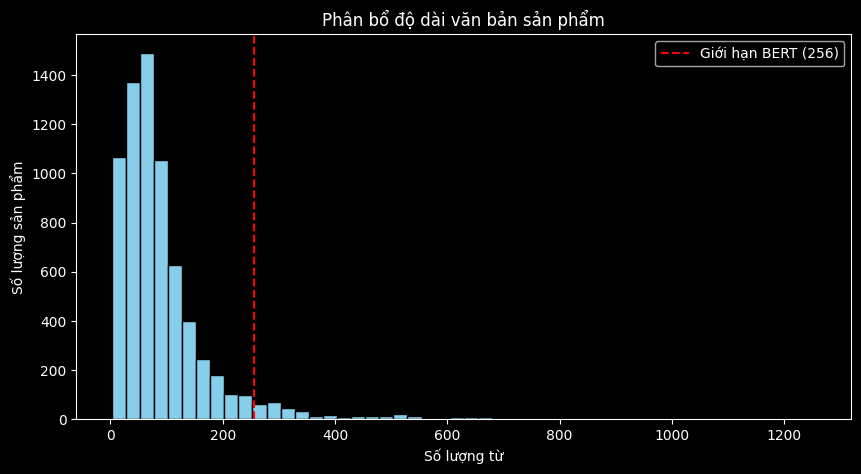

Độ dài trung bình: 94.33
Số sản phẩm dài hơn 256 từ: 371


In [ ]:
import matplotlib.pyplot as plt

# 1. Tính độ dài (số từ) của mỗi câu
doc_lengths = [len(s.split()) for s in df["sentences"]]

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.hist(doc_lengths, bins=50, color="skyblue", edgecolor="black")
plt.title("Phân bổ độ dài văn bản sản phẩm")
plt.xlabel("Số lượng từ")
plt.ylabel("Số lượng sản phẩm")
plt.axvline(x=256, color="red", linestyle="--", label="Giới hạn BERT (256)")
plt.legend()
plt.show()

# 3. Thống kê nhanh
print(f"Độ dài trung bình: {sum(doc_lengths)/len(doc_lengths):.2f}")
print(f"Số sản phẩm dài hơn 256 từ: {sum(1 for l in doc_lengths if l > 256)}")

In [233]:
from collections import Counter
import re

# Gộp tất cả thành một chuỗi khổng lồ, chuyển về chữ thường
all_text = " ".join(df["sentences"]).lower()
# Chỉ lấy các từ (loại bỏ dấu câu)
words = re.findall(r"\w+", all_text)

# Đếm tần suất
word_counts = Counter(words)
print("Top 20 từ phổ biến nhất:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

Top 20 từ phổ biến nhất:
the: 27715
and: 25675
to: 15926
a: 13726
for: 11445
baby: 9047
of: 8917
with: 8878
is: 8325
in: 7837
your: 6383
s: 5946
it: 4578
or: 3853
that: 3848
are: 3841
you: 3792
on: 3778
this: 3322
from: 3256


In [164]:
# %pip install seaborn

C:\Users\thanh\AppData\Local\Temp\ipykernel_27552\3968219736.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Count", y="Text", data=df_ngram, palette="viridis")


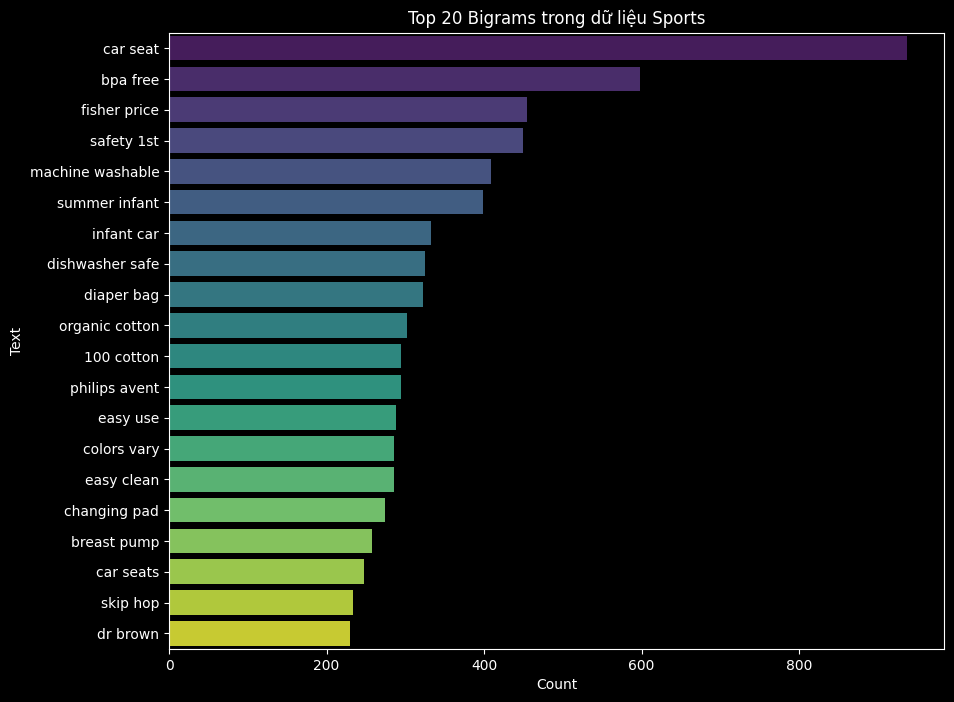

In [234]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt


def plot_top_ngrams(corpus, n=2, top_k=20):
    # Khởi tạo vectorizer để đếm cụm n-từ
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english").fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    # Lấy tần suất
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    # Vẽ biểu đồ
    df_ngram = pd.DataFrame(words_freq, columns=["Text", "Count"])
    plt.figure(figsize=(10, 8))
    sns.barplot(x="Count", y="Text", data=df_ngram, palette="viridis")
    plt.title(f"Top {top_k} Bigrams trong dữ liệu Sports")
    plt.show()


# Chạy thử với danh sách sentences của bạn
plot_top_ngrams(df["sentences"], n=2)

Giá trị nhỏ nhất: 2
Tứ phân vị Q1 (25%): 42.0
Trung vị (50%): 70.0
Tứ phân vị Q3 (75%): 113.0
Giá trị lớn nhất: 1257


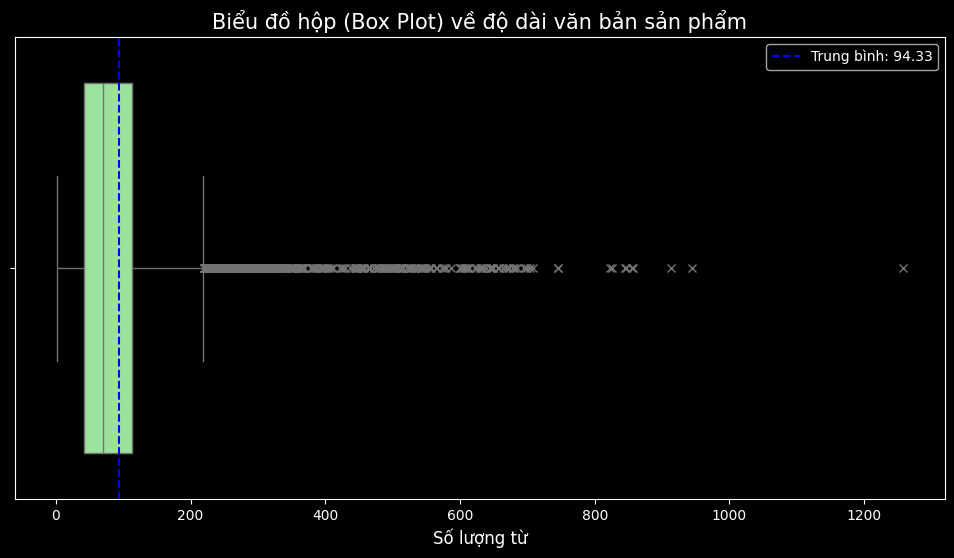

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán số lượng từ cho mỗi sản phẩm
doc_lengths = [len(s.split()) for s in df["sentences"]]

# 2. Khởi tạo khung hình
plt.figure(figsize=(12, 6))

# 3. Vẽ Box Plot nằm ngang
sns.boxplot(
    x=doc_lengths,
    color="lightgreen",
    flierprops={"marker": "x", "markerfacecolor": "red"},
)

# 4. Thêm các đường thông số quan trọng
mean_val = np.mean(doc_lengths)
plt.axvline(mean_val, color="blue", linestyle="--", label=f"Trung bình: {mean_val:.2f}")

# 5. Tinh chỉnh tiêu đề và nhãn
plt.title("Biểu đồ hộp (Box Plot) về độ dài văn bản sản phẩm", fontsize=15)
plt.xlabel("Số lượng từ", fontsize=12)
plt.legend()

# 6. Hiển thị các chỉ số thống kê cơ bản lên màn hình
quartiles = np.percentile(doc_lengths, [25, 50, 75])
print(f"Giá trị nhỏ nhất: {min(doc_lengths)}")
print(f"Tứ phân vị Q1 (25%): {quartiles[0]}")
print(f"Trung vị (50%): {quartiles[1]}")
print(f"Tứ phân vị Q3 (75%): {quartiles[2]}")
print(f"Giá trị lớn nhất: {max(doc_lengths)}")

plt.show()

In [ ]:
# %pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# list(set(df["price_tag"]))

['mid-range price', 'low price budget friendly', 'high price luxury premium']

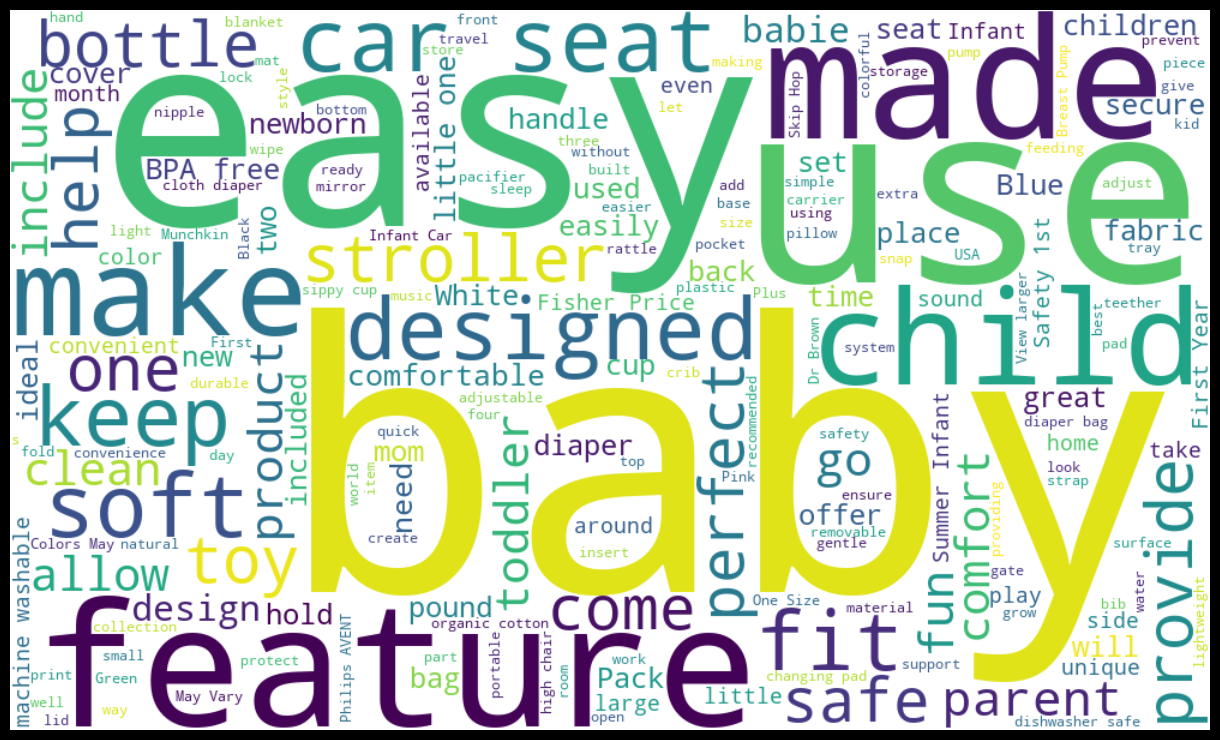

In [236]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# 1. Gom tất cả các câu trong danh sách 'sentences' thành một chuỗi văn bản khổng lồ
text_data = " ".join(df["sentences"])

# 2. Thiết lập các từ muốn loại bỏ (Stopwords)
# Ngoài stopwords mặc định của tiếng Anh, bạn có thể thêm các từ xuất hiện quá nhiều nhưng vô nghĩa
my_stopwords = set(STOPWORDS)
my_stopwords.update(
    # ["baby", "item", "product", "will", "use"]
)  # Ví dụ nếu từ 'baby' quá to chiếm hết chỗ

# 3. Khởi tạo WordCloud
wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=my_stopwords,
    max_words=200,  # Chỉ hiện 200 từ phổ biến nhất
    colormap="viridis",  # Màu sắc (có thể chọn: 'plasma', 'magma', 'inferno')
    min_font_size=10,
).generate(text_data)

# 4. Hiển thị bằng Matplotlib
plt.figure(figsize=(12, 8), facecolor=None)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Tắt trục tọa độ
plt.tight_layout(pad=0)

plt.show()

# (Tùy chọn) Lưu ảnh ra file
# wordcloud.to_file("my_wordcloud.png")

In [ ]:
# %pip install sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [244]:
# should `pip install sentence_transformers` first
# should use gpu to speed up
# https://www.sbert.net/docs/sentence_transformer/pretrained_models.html

from sentence_transformers import SentenceTransformer

# all-MiniLM-L6-v2, all-MiniLM-L12-v2, all-mpnet-base-v2 gpu (31s) (36s) (3p)

model_name = "all-MiniLM-L12-v2"

model = SentenceTransformer(model_name)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8401.78it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
# !pip install fastembed -q

In [4]:
# from fastembed import TextEmbedding

# # https://qdrant.github.io/fastembed/examples/Supported_Models/#supported-text-embedding-models
# model = TextEmbedding(model_name="BAAI/bge-small-en-v1.5")
# print("Đang encode...")

# embeddings_generator = model.embed(sentences)
# sentence_embeddings = np.array(list(embeddings_generator))

# print(f"Shape: {sentence_embeddings.shape}")


# np.save(os.path.join('text_feat.npy'), sentence_embeddings)
# print('Đã lưu xong bằng FastEmbed!')

In [245]:
!nvidia-smi

Sat Mar 28 22:31:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   39C    P4             11W /   74W |    1368MiB /   6141MiB |     31%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [246]:
sentences = df["sentences"].tolist()

In [248]:
sentences[:3]

["Baby Tracker® - Daily Childcare Journal, Schedule Log Time Too Easily keep track of your baby's or child's daily schedules, activities and needs in one handy spot. And make the drop-off and pick-up process for childcare a snap. The Baby Tracker Daily Childcare Journal is designed to make it fast and easy to record and review meals, naps, activities, playtime, daily news, milestones and to-dos ---all in a single page view. Get ready for doctor visits, give to childcare helpers and use this easy at-a-glance daily record to monitor schedules and prep for your baby's daily needs. This version records daily activities from 6 a.m. to 7 p.m. and creates a visual snapshot of activities by time each day. The Baby Tracker Daily Childcare Journal is ready to keep track of up to 6 months of daily schedule tracking (180 days) and is spiral bound to make it portable and lay flat for easy recording on a countertop or nightstand.Each journal includes:*180 daily at-a-glance tracking records (90 pages

In [ ]:
print("Bắt đầu Encode... Vui lòng đợi trong giây lát.")
with torch.no_grad():
    sentence_embeddings = model.encode(
        sentences, batch_size=64, show_progress_bar=True, convert_to_numpy=True
    )

print(f"Text encoded! Shape: {sentence_embeddings.shape}")

assert sentence_embeddings.shape[0] == df.shape[0]
save_path = os.path.join(PATH, "text_feat.npy")
np.save(save_path, sentence_embeddings)

print(f"Done! File đã được lưu tại: {save_path}")

Bắt đầu Encode... Vui lòng đợi trong giây lát.


Batches: 100%|██████████| 110/110 [00:09<00:00, 11.73it/s]


Text encoded! Shape: (7025, 384)
Done! File đã được lưu tại: ./data/2014\text_feat.npy


In [ ]:
# !pip install nvitop

In [ ]:
# !nvitop

In [263]:
sentence_embeddings[:10]

array([[-0.03870089,  0.04137528, -0.04921814, ...,  0.0060146 ,
        -0.00270388,  0.01575587],
       [-0.07176267,  0.02579845, -0.05509001, ...,  0.03911527,
         0.02566127,  0.05012527],
       [ 0.06807282,  0.05226178,  0.07950804, ...,  0.01990456,
         0.0278563 ,  0.02242634],
       ...,
       [-0.01831116,  0.10944589, -0.05371508, ..., -0.0220341 ,
         0.03325962, -0.0028114 ],
       [-0.03137589,  0.01566121, -0.06007652, ...,  0.08089005,
        -0.0270541 ,  0.10471443],
       [-0.03313181,  0.07066002, -0.05732198, ..., -0.02656337,
         0.09392525,  0.02094794]], shape=(10, 384), dtype=float32)

# Image encoder (V0)，following LATTICE, averaging over for missed items


In [ ]:
df[:5]

In [6]:
df = pd.read_parquet(os.path.join(PATH, "df_meta.2feat-encoder.parquet"))

In [7]:
import array


def read_image_features(path, feature_size):
    if not os.path.exists(path):
        return
    with open(path, "rb") as f:
        while True:
            asin_bytes = f.read(10)
            if not asin_bytes:
                break
            try:
                asin = asin_bytes.decode("utf-8").strip()
                a = array.array("f")
                # Đọc đúng số lượng float bạn yêu cầu
                a.fromfile(f, feature_size)
                yield asin, a.tolist()
            except EOFError:
                break
            except Exception as e:
                print(f"Lỗi tại vị trí {f.tell()}: {e}")
                break

In [28]:
# --- CẤU HÌNH ---
FEATURE_SIZE = 4096
FILE_B_PATH = os.path.join(PATH, "image_feature.vgg16.b")

In [29]:
image_features = read_image_features(FILE_B_PATH, feature_size=FEATURE_SIZE)

In [30]:
# Lấy thử 1 phần tử đầu tiên
first_item = next(image_features)

# Kiểm tra hình dạng
print(f"Kiểu dữ liệu của 1 phần tử: {type(first_item)}")
print(f"Mã ASIN (ID sản phẩm): {first_item[0]}")
print(f"Độ dài vector ảnh: {len(first_item[1])}")
print(f"5 giá trị đầu tiên trong vector: {first_item[1][:5]}")

Kiểu dữ liệu của 1 phần tử: <class 'tuple'>
Mã ASIN (ID sản phẩm): B004LE8ZYO
Độ dài vector ảnh: 4096
5 giá trị đầu tiên trong vector: [0.0, 0.0, 0.0, 0.0, 0.0]


In [21]:
first_item[1][:10]

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.6348890066146851,
 0.0,
 0.10182002186775208,
 0.0,
 0.0]

In [ ]:
from tqdm import tqdm

num_items = len(df)
OUTPUT_NPY = os.path.join(PATH, "image_feat.npy")

# 1. Tạo bản đồ tra cứu ASIN -> itemID (Dùng Dictionary để tìm kiếm O(1))
map_asin_itemID = dict(zip(df["asin"], df["itemID"]))

# 2. KHỞI TẠO MA TRẬN TRỐNG (Pre-allocation)
final_matrix = np.zeros((num_items, FEATURE_SIZE), dtype=np.float32)

# Tập hợp để kiểm tra những ID nào đã được điền dữ liệu
filled_indices = set()

print(f"🚀 Đang xử lý {num_items} sản phẩm...")

# 3. VỪA ĐỌC VỪA ĐIỀN (Single Pass)
# Chỉ lặp đúng 1 lần qua file .b, không tốn bộ nhớ đệm trung gian
for asin, feat_list in tqdm(
    read_image_features(FILE_B_PATH, FEATURE_SIZE), desc="Đang trích xuất"
):
    if asin in map_asin_itemID:
        target_idx = int(map_asin_itemID[asin])

        # Điền thẳng vào đúng "ngăn kệ" của nó trong ma trận
        final_matrix[target_idx] = feat_list
        filled_indices.add(target_idx)

# 4. KIỂM TRA DỮ LIỆU THIẾU (Safety Check)
all_indices = set(range(num_items))
missing_indices = sorted(list(all_indices - filled_indices))

if missing_indices:
    # Nếu thiếu dù chỉ 1 cái, lưu log và báo lỗi ngay để bảo vệ Model
    err_log = os.path.join(PATH, "ERR_missing_itemIDs.csv")
    np.savetxt(err_log, missing_indices, delimiter=",", fmt="%d")

    raise ValueError(
        f"❌ LỖI: Thiếu {len(missing_indices)} ảnh!\n"
        f"Dữ liệu không đủ để train model. Xem chi tiết tại: {err_log}"
    )

# 5. LƯU KẾT QUẢ
np.save(OUTPUT_NPY, final_matrix)

print(f"✅ Hoàn thành! File đã lưu: {OUTPUT_NPY}")
print(f"Kích thước ma trận cuối cùng: {final_matrix.shape}")

🚀 Đang xử lý 7025 sản phẩm...


Đang trích xuất: 7037it [00:00, 7088.21it/s]

✅ Hoàn thành! File đã lưu: ./data/2014\image_feat.npy
Kích thước ma trận cuối cùng: (7025, 4096)
